# The Derivative of $e^x$

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **the derivative of the
exponential function** (Week 1 — Derivatives and Optimization).

This notebook explains:

- the remarkable property that $e^x$ is **its own derivative**
- a numerical verification at $x = 2$ (secant slopes $\to e^2 = 7.39$)
- the result $\dfrac{d}{dx}e^x = e^x$, with the key limit $\dfrac{e^{\Delta x}-1}{\Delta x} \to 1$
- visualizations confirming the tangent slope equals the height everywhere

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Meaning of the Exponential $e$*.

## 1. $e^x$ is its own derivative

The exponential function $y = e^x$ has a unique property: at every point, the **slope of the
tangent equals the height of the curve**.

At a point $x$, the graph point is $(x,\, e^x)$ — height $e^x$ — and the tangent there has
slope $e^x$. In symbols:

$$
\frac{d}{dx}e^x = e^x .
$$

Let's verify it numerically.

## 2. Numerical verification at $x = 2$

At $x = 2$ the point is $(2,\, e^2) = (2,\, 7.39)$. Shrink $\Delta x$ and watch the secant
slope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return np.exp(x)

x0 = 2.0
print(f"{'Δx':>10} | {'Δf':>10} | {'slope Δf/Δx':>12}")
print("-" * 38)
for dx in [1, 1/2, 1/4, 1/8, 1/16, 1/1000]:
    df = f(x0 + dx) - f(x0)
    print(f"{dx:>10.4f} | {df:>10.5f} | {df/dx:>12.5f}")
print(f"\n-> the slope approaches e² = {np.e**2:.5f}, the height at x=2.")

        Δx |         Δf |  slope Δf/Δx
--------------------------------------
    1.0000 |   12.69648 |     12.69648
    0.5000 |    4.79344 |      9.58688
    0.2500 |    2.09868 |      8.39472
    0.1250 |    0.98384 |      7.87073
    0.0625 |    0.47655 |      7.62485
    0.0010 |    0.00739 |      7.39275

-> the slope approaches e² = 7.38906, the height at x=2.


## 3. Why: the key limit

The secant slope at $x$ is

$$
\frac{e^{x+\Delta x} - e^x}{\Delta x}
= e^x \cdot \frac{e^{\Delta x} - 1}{\Delta x}.
$$

The exponential factors out, and the remaining piece tends to $1$:

$$
\frac{e^{\Delta x} - 1}{\Delta x} \;\xrightarrow[\Delta x \to 0]{}\; 1 .
$$

So the derivative is $e^x \cdot 1 = e^x$:

$$
\boxed{\;\frac{d}{dx}e^x = e^x.\;}
$$

In [2]:
x, dx = sp.symbols('x Delta_x')

# the special limit
print("lim_{Δx->0} (e^Δx - 1)/Δx =", sp.limit((sp.exp(dx) - 1)/dx, dx, 0))

# the full derivative from the definition
print("d/dx e^x (limit definition) =",
      sp.simplify(sp.limit((sp.exp(x + dx) - sp.exp(x))/dx, dx, 0)))
print("SymPy d/dx e^x =", sp.diff(sp.exp(x), x))

lim_{Δx->0} (e^Δx - 1)/Δx = 1
d/dx e^x (limit definition) = exp(x)
SymPy d/dx e^x = exp(x)


In [3]:
# numerically watch (e^Δx - 1)/Δx -> 1
print("(e^Δx - 1)/Δx as Δx shrinks:")
for dx in [1, 0.1, 0.01, 0.001, 1e-6]:
    print(f"  Δx={dx:<8}: {(np.exp(dx)-1)/dx:.6f}")

(e^Δx - 1)/Δx as Δx shrinks:
  Δx=1       : 1.718282
  Δx=0.1     : 1.051709
  Δx=0.01    : 1.005017
  Δx=0.001   : 1.000500
  Δx=1e-06   : 1.000000


## 4. Visualizing

**Left:** secants on $y = e^x$ at $x = 2$ converging to the tangent of slope $e^2 \approx
7.39$. **Right:** $e^x$ and its derivative are the **same curve** — slope equals height
everywhere.

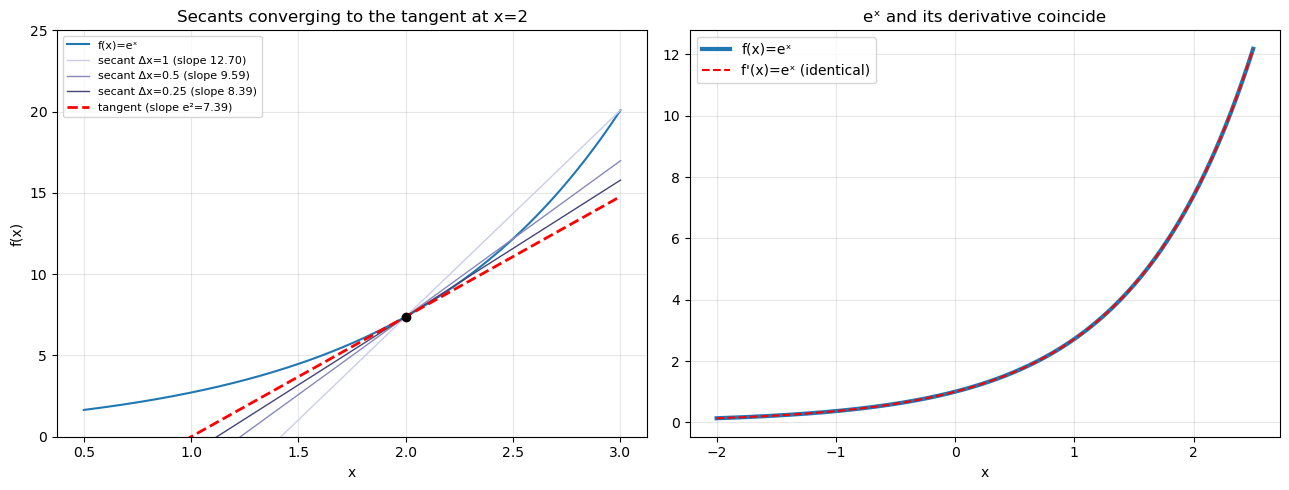

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

xs = np.linspace(0.5, 3, 200)
axes[0].plot(xs, np.exp(xs), label="f(x)=eˣ")
for dx, col in zip([1, 0.5, 0.25], ["#cce", "#88b", "#447"]):
    slope = (np.exp(2+dx) - np.exp(2))/dx
    axes[0].plot(xs, np.exp(2) + slope*(xs-2), color=col, lw=1, label=f"secant Δx={dx} (slope {slope:.2f})")
axes[0].plot(xs, np.exp(2) + np.exp(2)*(xs-2), "r--", lw=2, label=f"tangent (slope e²={np.e**2:.2f})")
axes[0].plot(2, np.exp(2), "ko")
axes[0].set_title("Secants converging to the tangent at x=2")
axes[0].set_xlabel("x"); axes[0].set_ylabel("f(x)")
axes[0].set_ylim(0, 25); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=8)

xs2 = np.linspace(-2, 2.5, 200)
axes[1].plot(xs2, np.exp(xs2), label="f(x)=eˣ", lw=3)
axes[1].plot(xs2, np.exp(xs2), "r--", label="f'(x)=eˣ (identical)")
axes[1].set_title("eˣ and its derivative coincide")
axes[1].set_xlabel("x"); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Exercises

### Basic
1. What is the derivative of $f(x) = e^x$?
2. What is the slope of the tangent to $e^x$ at $x = 0$? At $x = 2$?

### Intermediate
3. Estimate the slope of $e^x$ at $x = 0$ numerically and compare to $e^0$.
4. What is the value of $\lim_{\Delta x \to 0}\dfrac{e^{\Delta x}-1}{\Delta x}$?

### Advanced
5. Using the chain rule (preview), what is $\dfrac{d}{dx}e^{3x}$?
6. Explain why "slope equals height" makes $e^x$ model processes whose growth rate is
   proportional to their current size.

## 6. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 2.
print("2. slope at x=0:", sp.diff(sp.exp(x), x).subs(x, 0), "; at x=2:", float(sp.diff(sp.exp(x), x).subs(x, 2)))

# 3.
dx = 1e-6
print(f"3. numeric slope at 0: {(np.exp(dx)-np.exp(0))/dx:.6f}  (exact e^0 = 1)")

# 4.
print("4. limit =", sp.limit((sp.exp(sp.Symbol('h'))-1)/sp.Symbol('h'), sp.Symbol('h'), 0))

# 5.
print("5. d/dx e^(3x) =", sp.diff(sp.exp(3*x), x))

print("\n1. e^x.")
print("6. dy/dx = y means the rate of change equals the current amount -> exponential growth.")

2. slope at x=0: 1 ; at x=2: 7.38905609893065
3. numeric slope at 0: 1.000000  (exact e^0 = 1)
4. limit = 1
5. d/dx e^(3x) = 3*exp(3*x)

1. e^x.
6. dy/dx = y means the rate of change equals the current amount -> exponential growth.


## 7. Conclusion

- The exponential $f(x) = e^x$ is **its own derivative**: $\dfrac{d}{dx}e^x = e^x$.
- Numerically, the secant slopes at $x = 2$ converge to $e^2 = 7.39$ — the height there.
- The reason is the factorization $\dfrac{e^{x+\Delta x}-e^x}{\Delta x} = e^x\,\dfrac{e^{\Delta x}-1}{\Delta x}$
  with $\dfrac{e^{\Delta x}-1}{\Delta x} \to 1$.
- "Slope equals height" is why $e^x$ governs any process whose growth rate is proportional
  to its current value — and it makes $e^x$ wonderfully easy to differentiate.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (14).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **the derivative of $e^x$**. Key spoken points, lightly cleaned:

> A key property of $e$ is that the exponential function $y = e^x$ is its own derivative: at
> a point $x$ the graph point is $(x, e^x)$, and the tangent there has slope $e^x$, so $e^x$
> equals its own slope. Verify numerically at $x = 2$, where the point is $(2, 7.39)$ since
> $e^2 = 7.39$. Secant slopes: $\Delta x = 1$ gives $e^3 - e^2 = 12.7$, slope $12.7$;
> $\Delta x = 1/2$ gives $\Delta f = 4.79$, slope $9.59$; $1/4$ gives $8.39$; $1/8$ gives
> $7.87$; $1/16$ gives $7.62$; $1/1000$ gives $7.39$ — approaching $e^2 = 7.39$. So the
> tangent at $(2, e^2)$ has slope $e^2$, and at every point the tangent at $(x, e^x)$ has
> slope $e^x$.